In [1]:
from elos import EloTracker
from utils import load_all_games_csv, get_teams, predict_lr_use_pitchers_if_first_games
from simulation import SimpleMLBSimulator, PAMLBSimulator
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import r2_score

# Simulation

This notebook focuses on simulating a given season via Elo ratings ratings, estimating each team's probability of making it to the playoffs and different rounds within them.

It then calculates the r^2 between actual and predicted wins for the season.

In [2]:
season = 2025

## Get Divisions and Leagues for Teams

In [3]:
# Get divisions and leagues for each team
AL_EAST = {'TOR', 'NYA', 'BOS', 'TBA', 'BAL'}
AL_CENTRAL = {'CLE', 'DET', 'KCA', 'MIN', 'CHA'}
#AL_WEST = {'SEA', 'HOU', 'TEX', 'OAK', 'ANA'}
AL_WEST = {'SEA', 'HOU', 'TEX', 'ATH', 'ANA'}
AL = [AL_EAST, AL_CENTRAL, AL_WEST]

NL_EAST = {'PHI', 'NYN', 'MIA', 'ATL', 'WAS'}
NL_CENTRAL = {'MIL', 'CHN', 'CIN', 'SLN', 'PIT'}
NL_WEST = {'LAN', 'SDN', 'SFN', 'ARI', 'COL'}

NL = NL_EAST, NL_CENTRAL, NL_WEST

TEAMS = AL_EAST | AL_CENTRAL | AL_WEST | NL_EAST | NL_CENTRAL | NL_WEST
TEAMS

{'ANA',
 'ARI',
 'ATH',
 'ATL',
 'BAL',
 'BOS',
 'CHA',
 'CHN',
 'CIN',
 'CLE',
 'COL',
 'DET',
 'HOU',
 'KCA',
 'LAN',
 'MIA',
 'MIL',
 'MIN',
 'NYA',
 'NYN',
 'PHI',
 'PIT',
 'SDN',
 'SEA',
 'SFN',
 'SLN',
 'TBA',
 'TEX',
 'TOR',
 'WAS'}

## Get Elo Ratings for each team

In [4]:
all_games = load_all_games_csv(preprocess=True)
games_before = all_games[all_games['season'] < season] # Up to season

teams = get_teams(games_before)
et = EloTracker()

et.add_history(games_before)

# Get dict of latest elos for teams
#elos_map = {team: et.elos_map[team][0] for team in TEAMS}
elos_map = {team: et.elos_map[team][0] for team in (TEAMS | {'OAK'}) - {'ATH'}}
elos_map['ATH'] = et.elos_map['OAK'][0]

# Revert to mean by 1/3 for new season
elos_map = {team: elos_map[team] + (1500 - elos_map[team]) / 3 for team in TEAMS}

elos_map

/Users/lancehendricks/Documents/College Coding/ML/Elo Ratings/analysis/src/utils/misc_utils.py:41: DtypeWarning: Columns (10,11,13,17,19,20,21,27,28) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(CLEAN_DATA_DIR / filename)


{'LAN': 1543.4531570264198,
 'SDN': 1523.9338488249748,
 'SLN': 1501.475780378102,
 'CLE': 1510.3684505749704,
 'MIN': 1498.029487442219,
 'MIA': 1474.8425358668817,
 'CIN': 1491.346298436719,
 'ANA': 1464.2556058241114,
 'CHN': 1502.8983221771189,
 'WAS': 1476.3742822615345,
 'MIL': 1520.8962222440791,
 'NYN': 1516.1993638221697,
 'HOU': 1520.0027065050556,
 'ATL': 1522.6776363652439,
 'TOR': 1495.5159210103802,
 'SFN': 1498.8203286993905,
 'KCA': 1491.9308675960867,
 'PHI': 1522.731826710146,
 'COL': 1462.099952940796,
 'PIT': 1486.1727607963771,
 'NYA': 1521.865698858941,
 'BAL': 1517.1047622196943,
 'ARI': 1514.5682422324635,
 'ATH': 1467.6783484973278,
 'TEX': 1498.5358956818375,
 'SEA': 1510.3629520246325,
 'DET': 1505.9052275046763,
 'BOS': 1498.0906207045605,
 'TBA': 1509.6581249129413,
 'CHA': 1432.28608563123}

## Get Schedule

In [5]:
schedule_df = all_games[(all_games['season'] == season) & (all_games['gametype'] == 'regular')]
schedule_df.head()

,visteam,hometeam,site,date,number,starttime,daynight,innings,tiebreaker,usedh,...,vispitcherminusteamrgs,homefirstpitchergameofseason,visfirstpitchergameofseason,homelastkwinpct,vislastkwinpct,adjustedvisrestdays,adjustedhomerestdays,adjustedhomedistancetraveled,adjustedvisdistancetraveled,adjustedmarginofvictory
gid,,,,,,,,,,,,,,,,,,,,,
CHN202503180,LAN,CHN,TOK01,20250318,0.0,7:10PM,night,9.0,2.0,True,...,3.894620,True,True,NaN,NaN,3.0,3.0,0.0,17.623476,1.732051
CHN202503190,LAN,CHN,TOK01,20250319,0.0,7:10PM,night,9.0,2.0,True,...,-23.900000,True,True,0.0,1.0,1.0,1.0,0.0,0.000000,1.732051
ARI202503270,CHN,ARI,PHO01,20250327,0.0,7:10PM,night,9.0,2.0,True,...,-12.000000,True,False,NaN,0.0,3.0,3.0,0.0,17.947542,2.000000
CHA202503270,ANA,CHA,CHI12,20250327,0.0,3:10PM,day,9.0,2.0,True,...,4.239583,True,True,NaN,NaN,3.0,3.0,0.0,12.007542,2.645751
CIN202503270,SFN,CIN,CIN09,20250327,0.0,4:10PM,day,9.0,2.0,True,...,2.735129,True,True,NaN,NaN,3.0,3.0,0.0,12.677129,1.414214


## Simulate Seasons

In [16]:
sim = SimpleMLBSimulator(schedule_df, AL, NL, elos_map, elo_prob_func=predict_lr_use_pitchers_if_first_games, simulate_mov=True)
sim.simulate_seasons(1000)
team_results = sim.team_results

100%|██████████| 1000/1000 [01:52<00:00,  8.86it/s]


In [17]:
# Get DF of results
avg_wins = [team_results[team][0] for team in TEAMS]
playoff_pcts = [team_results[team][1] for team in TEAMS]
div_pcts = [team_results[team][2] for team in TEAMS]
champ_pcts = [team_results[team][3] for team in TEAMS]
ws_pcts = [team_results[team][4] for team in TEAMS]
winner_pcts = [team_results[team][5] for team in TEAMS]

# Make PD dataframe to easily visualize
results_df = pd.DataFrame({'Team':list(TEAMS), 'Avg. Wins':avg_wins, 'Playoff %':playoff_pcts,
                           'Divisional %':div_pcts, 'Championship %':champ_pcts, 'WS %':ws_pcts, 'Win WS %':winner_pcts})
results_df = results_df.sort_values(by='Win WS %', ascending=False).reset_index(drop=True)
results_df

,Team,Avg. Wins,Playoff %,Divisional %,Championship %,WS %,Win WS %
0,LAN,91.271,75.1,55.2,30.2,15.8,8.2
1,HOU,87.403,62.5,45.3,25.4,13.9,7.6
2,MIL,86.751,56.9,40.6,21.3,10.2,5.6
3,SDN,86.690,54.8,37.4,19.2,9.9,5.5
4,ATL,86.762,58.6,40.7,19.4,9.9,5.4
5,NYA,86.853,59.3,41.4,20.4,10.7,5.2
6,CLE,85.744,55.3,37.4,19.0,10.5,4.9
7,TBA,83.884,48.6,33.8,17.4,9.4,4.9
8,NYN,85.336,51.2,36.1,18.7,10.2,4.8
9,DET,84.065,50.3,34.7,19.0,8.5,4.7


## Compare With Actual Data

In [18]:
actual_team_wins_map = {team: 0 for team in TEAMS}

for _, row in schedule_df.iterrows():
    home = row['hometeam']
    away = row['visteam']
    home_won = row['homewon']
    actual_team_wins_map[home] += home_won
    actual_team_wins_map[away] += 1 - home_won
    
actual_team_wins = [actual_team_wins_map[team] for team in TEAMS]


### Plot actual vs predicted



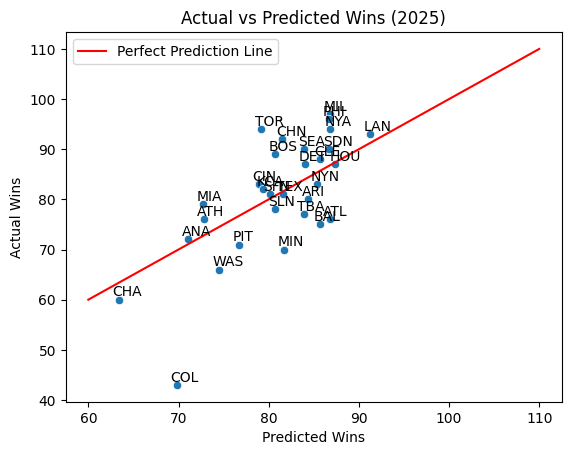

In [19]:
avg_wins_np = np.array(avg_wins)
actual_wins_np = np.array(actual_team_wins)

sns.scatterplot(x=avg_wins_np, y=actual_wins_np)
plt.xlabel('Predicted Wins')
plt.ylabel('Actual Wins')
plt.title(f'Actual vs Predicted Wins ({season})')

# Label points
for i, team in enumerate(TEAMS):
    plt.text(x=avg_wins_np[i] - 0.7, y=actual_wins_np[i] + 0.7, s=team)
    
# Line with slope 1 (perfect)
xp = np.linspace(60,110)
yp = xp
plt.plot(xp, yp, color='red', label='Perfect Prediction Line')

plt.legend()

### r^2 Score

In [20]:
r2_score(actual_wins_np, avg_wins_np)

0.48050510030241933

### r^2 Score Baseline: FanGraphs

In [14]:
fangraphs_team_wins_map = {
    'LAN': 96,   # Dodgers
    'ATL': 93,   # Braves
    'PHI': 87,   # Phillies
    'NYN': 86,   # Mets
    'ARI': 86,   # Diamondbacks
    'NYA': 86,   # Yankees
    'BOS': 85,   # Red Sox
    'TEX': 84,   # Rangers
    'SEA': 84,   # Mariners
    'CHN': 84,   # Cubs
    'HOU': 84,   # Astros
    'BAL': 83,   # Orioles
    'MIN': 83,   # Twins
    'TOR': 83,   # Blue Jays
    'SDN': 82,   # Padres
    'DET': 82,   # Tigers
    'TBA': 82,   # Rays
    'SFN': 81,   # Giants
    'MIL': 81,   # Brewers
    'KCA': 81,   # Royals
    'SLN': 79,   # Cardinals
    'PIT': 78,   # Pirates
    'CIN': 78,   # Reds
    'CLE': 78,   # Guardians
    'ATH': 76,   # Athletics
    'ANA': 76,   # Angels
    'WAS': 73,   # Nationals
    'MIA': 71,   # Marlins
    'COL': 65,   # Rockies
    'CHA': 63    # White Sox
}



fangraphs_wins_np = np.array([fangraphs_team_wins_map[team] for team in TEAMS])

In [15]:
r2_score(actual_wins_np, fangraphs_wins_np)

0.45967741935483875